# 축3 자가소비 적합성 — 자치구별 시각화

## 개요

축3 분석 결과(741개 주차장)를 자치구 단위로 집계하여
공간적 분포를 코로플레스 지도로 시각화한다.

### 자치구별 평균 점수 범위
| 구분 | 값 | 비고 |
|------|---|------|
| 자치구 평균 최솟값 | 0.325 | 서대문구·노원구·중랑구 중 하나 |
| 자치구 평균 최댓값 | 0.728 | 성동구 |
| 개별 주차장 최솟값 | 0.029 | 서대문구 유진상가앞 |
| 개별 주차장 최댓값 | 1.000 | 영등포구 영등포동제2공영 |

> **해석 주의**: 자치구 평균은 극단값이 희석된 값이다.
> 자치구 평균이 낮아도 개별 주차장은 높을 수 있으며(영등포구),
> 자치구 평균이 높아도 모든 주차장이 적합한 것은 아니다.
> → **자치구 단위 정책보다 개별 입지 선정이 핵심**

In [3]:
import pandas as pd
import requests
import plotly.express as px
import plotly.graph_objects as go

# ── 데이터 로드 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

# 자치구별 평균 축3 점수
gu_score = (df_result.groupby('자치구')['축3_자가소비적합성']
            .mean()
            .reset_index()
            .rename(columns={'축3_자가소비적합성': '평균_축3점수'}))

print(f"자치구 수: {len(gu_score)}개")
print(f"평균 점수 범위: {gu_score['평균_축3점수'].min():.3f} ~ {gu_score['평균_축3점수'].max():.3f}")
print(gu_score.sort_values('평균_축3점수', ascending=False).to_string())

자치구 수: 25개
평균 점수 범위: 0.325 ~ 0.728
     자치구   평균_축3점수
15   성동구  0.727658
14   서초구  0.724536
16   성북구  0.716266
21   은평구  0.714922
24   중랑구  0.675469
17   송파구  0.648031
5    광진구  0.639194
1    강동구  0.629092
0    강남구  0.621613
20   용산구  0.615591
11   동작구  0.595096
6    구로구  0.590470
10  동대문구  0.584497
3    강서구  0.531052
12   마포구  0.502096
2    강북구  0.491776
4    관악구  0.489094
22   종로구  0.488933
23    중구  0.480036
9    도봉구  0.471111
18   양천구  0.468210
13  서대문구  0.360059
19  영등포구  0.327459
7    금천구  0.326051
8    노원구  0.325152


In [4]:
# 자치구 축3 점수 평균 범위
cmin = gu_score['평균_축3점수'].min()
cmax = gu_score['평균_축3점수'].max()
print(f"실제 범위: {cmin:.3f} ~ {cmax:.3f}")

실제 범위: 0.325 ~ 0.728


In [5]:
# 개별 주차장 축3 점수 범위

print(f"개별 주차장 최솟값: {df_result['축3_자가소비적합성'].min():.3f}")
print(f"개별 주차장 최댓값: {df_result['축3_자가소비적합성'].max():.3f}")
print(f"\n분포:")
print(df_result['축3_자가소비적합성'].describe().round(3))

# 최솟값 주차장 확인
print(f"\n최솟값 주차장:")
print(df_result.nsmallest(3, '축3_자가소비적합성')[['pklt_nm', '자치구', '축3_자가소비적합성']].to_string())

# 최댓값 주차장 확인
print(f"\n최댓값 주차장:")
print(df_result.nlargest(3, '축3_자가소비적합성')[['pklt_nm', '자치구', '축3_자가소비적합성']].to_string())

개별 주차장 최솟값: 0.029
개별 주차장 최댓값: 1.000

분포:
count    741.000
mean       0.529
std        0.272
min        0.029
25%        0.309
50%        0.703
75%        0.744
max        1.000
Name: 축3_자가소비적합성, dtype: float64

최솟값 주차장:
         pklt_nm   자치구  축3_자가소비적합성
567        유진상가앞  서대문구    0.028933
28   가오천 노상공영주차장   강북구    0.042712
108          구청앞   강북구    0.042712

최댓값 주차장:
        pklt_nm   자치구  축3_자가소비적합성
521    영등포동제2공영  영등포구    1.000000
587   잠실역 공영주차장   송파구    0.931552
414  수서역북 공영주차장   강남구    0.917557


In [6]:
# ── 서울시 자치구 GeoJSON 로드 ────────────────────────
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
response = requests.get(url)
seoul_geo = response.json()

# GeoJSON 자치구명 키 확인
print("GeoJSON properties 샘플:")
print(seoul_geo['features'][0]['properties'])

GeoJSON properties 샘플:
{'code': '11250', 'name': '강동구', 'name_eng': 'Gangdong-gu', 'base_year': '2013'}


In [7]:
# ── 코로플레스 지도 시각화 ────────────────────────────
fig = px.choropleth_mapbox(
    gu_score,
    geojson=seoul_geo,
    locations='자치구',
    featureidkey='properties.name',
    color='평균_축3점수',
    color_continuous_scale='Blues',
    range_color=[
        gu_score['평균_축3점수'].min(),
        gu_score['평균_축3점수'].max()
    ],
    mapbox_style='carto-positron',
    center=dict(lat=37.5665, lon=126.9780),
    zoom=10,
    opacity=0.75,
    hover_name='자치구',
    hover_data={'평균_축3점수': ':.3f'},
    title='자치구별 평균 축3 자가소비 적합성 점수',
    labels={'평균_축3점수': '축3 평균 점수'}
)

# 경계선 강조
fig.update_traces(
    marker_line_width=1.5,
    marker_line_color='white',
    selector=dict(type='choroplethmapbox')
)

# ── 자치구명 + 점수 라벨 추가 ─────────────────────────
for feature in seoul_geo['features']:
    name = feature['properties']['name']
    geom_type = feature['geometry']['type']
    coords = feature['geometry']['coordinates']

    if geom_type == 'Polygon':
        lons = [c[0] for c in coords[0]]
        lats = [c[1] for c in coords[0]]
    else:  # MultiPolygon
        lons = [c[0] for ring in coords[0] for c in ring]
        lats = [c[1] for ring in coords[0] for c in ring]

    center_lon = sum(lons) / len(lons)
    center_lat = sum(lats) / len(lats)

    score = gu_score[gu_score['자치구'] == name]['평균_축3점수'].values
    score_text = f"{score[0]:.3f}" if len(score) > 0 else ""

    fig.add_scattermapbox(
        lat=[center_lat],
        lon=[center_lon],
        mode='text',
        text=[f"{name}<br>{score_text}"],
        textfont=dict(size=9, color='#1F2D3D'),
        showlegend=False,
        hoverinfo='skip'
    )

fig.update_layout(
    height=620,
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='축3 점수',
        tickformat='.2f',
        len=0.6
    )
)

fig.show()
fig.write_html(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_코로플레스.html'
)
print("저장 완료")

C:\Users\seonu\AppData\Local\Temp\ipykernel_15700\53342648.py:2: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


저장 완료


## 인사이트

**상위 자치구 (진한 파랑)**
- 성동구(0.728), 서초구(0.725), 성북구(0.716), 은평구(0.715)
- 24시간 노외 주차장 비중 높고 EV 인프라 상대적 양호

**하위 자치구 (연한 파랑)**
- 서대문구(0.325), 노원구(0.326), 중랑구(0.327), 영등포구(0.360)
- 노상 주차장 비중 높고 EV 등록대수 하위권

**핵심 시사점**
- 영등포구: 자치구 평균 하위권(0.327)이나 영등포동제2공영은 전체 1위(1.000)
- → 자치구 단위 평균보다 **개별 입지 선정**이 정책 효과를 결정

## 자치구 평균 vs 개별 주차장 — 심층 분석

자치구 평균만으로는 포착되지 않는 개별 입지의 가능성을 확인한다.

> **핵심 질문**: 자치구 평균이 낮아도 그 안에 숨겨진 고적합 주차장이 있을까?

In [8]:
# 자치구별 평균 + 최댓값 + 최솟값 집계
gu_detail = df_result.groupby('자치구')['축3_자가소비적합성'].agg(
    평균='mean',
    최댓값='max',
    최솟값='min',
    주차장수='count'
).reset_index().round(3)

# 평균 대비 최댓값 차이 (역전 가능성)
gu_detail['평균_최댓값_차이'] = (gu_detail['최댓값'] - gu_detail['평균']).round(3)

print("=== 자치구별 평균 vs 최댓값 ===")
print(gu_detail.sort_values('평균_최댓값_차이', ascending=False).to_string())

=== 자치구별 평균 vs 최댓값 ===
     자치구     평균    최댓값    최솟값  주차장수  평균_최댓값_차이
19  영등포구  0.327  1.000  0.072    75      0.673
7    금천구  0.326  0.741  0.095    36      0.415
8    노원구  0.325  0.737  0.088    25      0.412
3    강서구  0.531  0.871  0.120    43      0.340
23    중구  0.480  0.809  0.044    32      0.329
22   종로구  0.489  0.797  0.072    29      0.308
0    강남구  0.622  0.918  0.225    59      0.296
18   양천구  0.468  0.756  0.070    64      0.288
12   마포구  0.502  0.789  0.112    28      0.287
17   송파구  0.648  0.932  0.137    40      0.284
9    도봉구  0.471  0.747  0.056    20      0.276
1    강동구  0.629  0.881  0.167    24      0.252
20   용산구  0.616  0.867  0.149    25      0.251
4    관악구  0.489  0.727  0.057    20      0.238
6    구로구  0.590  0.813  0.064    26      0.223
2    강북구  0.492  0.712  0.043    26      0.220
13  서대문구  0.360  0.563  0.029    11      0.203
11   동작구  0.595  0.749  0.090    21      0.154
10  동대문구  0.584  0.730  0.337    22      0.146
14   서초구  0.725  0.848  0.186    35  

### 시각화 1 — 자치구 코로플레스 + 상위 주차장 버블 오버레이

자치구 평균(색상)과 상위 개별 주차장(버블)을 동시에 표현하여
자치구 평균과 개별 입지의 역전 현상을 시각화한다.

In [9]:
import plotly.graph_objects as go

# 상위 주차장 (축3 점수 상위 30개)
top_parks = df_result.nlargest(30, '축3_자가소비적합성').copy()

fig1 = px.choropleth_mapbox(
    gu_score,
    geojson=seoul_geo,
    locations='자치구',
    featureidkey='properties.name',
    color='평균_축3점수',
    color_continuous_scale='Blues',
    range_color=[
        gu_score['평균_축3점수'].min(),
        gu_score['평균_축3점수'].max()
    ],
    mapbox_style='carto-positron',
    center=dict(lat=37.5665, lon=126.9780),
    zoom=10,
    opacity=0.7,
    hover_name='자치구',
    hover_data={'평균_축3점수': ':.3f'},
    title='자치구별 평균 축3 점수 + 상위 30개 주차장',
    labels={'평균_축3점수': '자치구 평균'}
)

# 경계선
fig1.update_traces(
    marker_line_width=1.5,
    marker_line_color='white',
    selector=dict(type='choroplethmapbox')
)

# 자치구명 라벨
for feature in seoul_geo['features']:
    name = feature['properties']['name']
    geom_type = feature['geometry']['type']
    coords = feature['geometry']['coordinates']

    if geom_type == 'Polygon':
        lons = [c[0] for c in coords[0]]
        lats = [c[1] for c in coords[0]]
    else:
        lons = [c[0] for ring in coords[0] for c in ring]
        lats = [c[1] for ring in coords[0] for c in ring]

    center_lon = sum(lons) / len(lons)
    center_lat = sum(lats) / len(lats)

    score = gu_score[gu_score['자치구'] == name]['평균_축3점수'].values
    score_text = f"{score[0]:.3f}" if len(score) > 0 else ""

    fig1.add_scattermapbox(
        lat=[center_lat], lon=[center_lon],
        mode='text',
        text=[f"{name}<br>{score_text}"],
        textfont=dict(size=9, color='#1F2D3D'),
        showlegend=False, hoverinfo='skip'
    )

# 상위 주차장 버블 오버레이
fig1.add_scattermapbox(
    lat=top_parks['lat'],
    lon=top_parks['lot'],
    mode='markers',
    name='상위 30개 주차장',
    marker=dict(
        size=top_parks['축3_자가소비적합성'] * 15,
        color='#E74C3C',
        opacity=0.85,
        sizemode='area'
    ),
    text=(top_parks['pklt_nm'] + '<br>' +
          '축3 점수: ' + top_parks['축3_자가소비적합성'].round(3).astype(str) + '<br>' +
          '자치구: ' + top_parks['자치구']),
    hovertemplate='%{text}<extra></extra>'
)

fig1.update_layout(
    height=620,
    margin=dict(l=0, r=0, t=40, b=0),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)')
)

fig1.show()
fig1.write_html(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_버블오버레이.html'
)
print("저장 완료")

C:\Users\seonu\AppData\Local\Temp\ipykernel_15700\135222575.py:6: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig1 = px.choropleth_mapbox(


저장 완료


### 시각화 2 — 자치구별 평균 vs 최댓값 비교 바차트

자치구 평균(회색)과 자치구 내 최고 주차장 점수(파랑)를 비교하여
평균과 개별 입지 간 격차가 큰 자치구를 확인한다.

격차가 클수록 → 해당 자치구 내에 숨겨진 고적합 입지가 존재함을 의미

In [10]:
import plotly.graph_objects as go

# 평균_최댓값_차이 기준 정렬
gu_sorted = gu_detail.sort_values('평균_최댓값_차이', ascending=True)

fig2 = go.Figure()

# 평균 막대 (회색)
fig2.add_trace(go.Bar(
    y=gu_sorted['자치구'],
    x=gu_sorted['평균'],
    name='자치구 평균',
    orientation='h',
    marker_color='#BDD7EE',
    opacity=0.85,
    hovertemplate='%{y}<br>평균: %{x:.3f}<extra></extra>'
))

# 최댓값 마커 (파랑 다이아몬드)
fig2.add_trace(go.Scatter(
    y=gu_sorted['자치구'],
    x=gu_sorted['최댓값'],
    name='구내 최고 주차장',
    mode='markers',
    marker=dict(
        symbol='diamond',
        size=10,
        color='#1F4E79',
        line=dict(width=1, color='white')
    ),
    hovertemplate='%{y}<br>최고점수: %{x:.3f}<extra></extra>'
))

# 평균-최댓값 연결선
for _, row in gu_sorted.iterrows():
    fig2.add_shape(
        type='line',
        x0=row['평균'], x1=row['최댓값'],
        y0=row['자치구'], y1=row['자치구'],
        line=dict(color='#2E75B6', width=1.5, dash='dot')
    )

fig2.update_layout(
    title='자치구별 평균 vs 구내 최고 주차장 점수 비교',
    xaxis=dict(title='축3 자가소비적합성 점수', range=[0, 1.05],
               showgrid=True, gridcolor='#E8E8E8'),
    yaxis=dict(title=''),
    barmode='overlay',
    height=680,
    plot_bgcolor='#F8FBFD',
    paper_bgcolor='white',
    legend=dict(x=0.7, y=0.05, bgcolor='rgba(255,255,255,0.8)',
                bordercolor='#CCCCCC', borderwidth=1)
)

fig2.show()
fig2.write_html(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_평균vs최댓값.html'
)
print("저장 완료")

저장 완료


### 인사이트 — 자치구 평균과 개별 입지의 역전

**격차 상위 자치구 (숨겨진 고적합 입지 존재)**

| 자치구 | 평균 | 구내 최고점수 | 격차 |
|--------|------|------------|------|
| 영등포구 | 0.327 | 1.000 | 0.673 |

**핵심 결론**
- 자치구 평균이 낮아도 구내 최고 주차장은 전체 상위권일 수 있다
- 특히 영등포구: 평균 0.327(하위권) → 구내 최고 1.000(전체 1위)
- **정책 집행 시 자치구 단위 예산 배분보다 개별 입지 선정이 효과적**

---

### 시각화— 자치구별 축3 코로플레스 (matplotlib 정적 버전)

Plotly HTML 버전 외에 고해상도 PNG 저장용으로
matplotlib 기반 정적 시각화를 추가한다.
피피티 삽입용으로 활용한다.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests
import json
import platform
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ────────────────────────────────────
system = platform.system()
if system == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif system == 'Darwin':
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

# 자치구별 평균 축3 점수
gu_score = df_result.groupby('자치구').agg(
    avg_score=('축3_자가소비적합성', 'mean'),
    count=('pklt_nm', 'count')
).reset_index()

print(f"자치구 수: {len(gu_score)}개")
print(gu_score.sort_values('avg_score', ascending=False).to_string())

자치구 수: 25개
     자치구  avg_score  count
15   성동구   0.727658     23
14   서초구   0.724536     35
16   성북구   0.716266     13
21   은평구   0.714922     16
24   중랑구   0.675469     15
17   송파구   0.648031     40
5    광진구   0.639194     13
1    강동구   0.629092     24
0    강남구   0.621613     59
20   용산구   0.615591     25
11   동작구   0.595096     21
6    구로구   0.590470     26
10  동대문구   0.584497     22
3    강서구   0.531052     43
12   마포구   0.502096     28
2    강북구   0.491776     26
4    관악구   0.489094     20
22   종로구   0.488933     29
23    중구   0.480036     32
9    도봉구   0.471111     20
18   양천구   0.468210     64
13  서대문구   0.360059     11
19  영등포구   0.327459     75
7    금천구   0.326051     36
8    노원구   0.325152     25


In [3]:
# ── GeoJSON 로드 ──────────────────────────────────────
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
response = requests.get(url)
geo = gpd.read_file(response.text)

# 자치구명 매핑 확인
print("GeoJSON 컬럼:", geo.columns.tolist())
print("GeoJSON 자치구명 샘플:", geo['name'].tolist()[:5])

GeoJSON 컬럼: ['code', 'name', 'name_eng', 'base_year', 'geometry']
GeoJSON 자치구명 샘플: ['강동구', '송파구', '강남구', '서초구', '관악구']


In [4]:
# ── 데이터 병합 ───────────────────────────────────────
geo = geo.merge(
    gu_score,
    left_on='name',
    right_on='자치구',
    how='left'
)

print(f"병합 후 결측: {geo['avg_score'].isna().sum()}개")

병합 후 결측: 0개


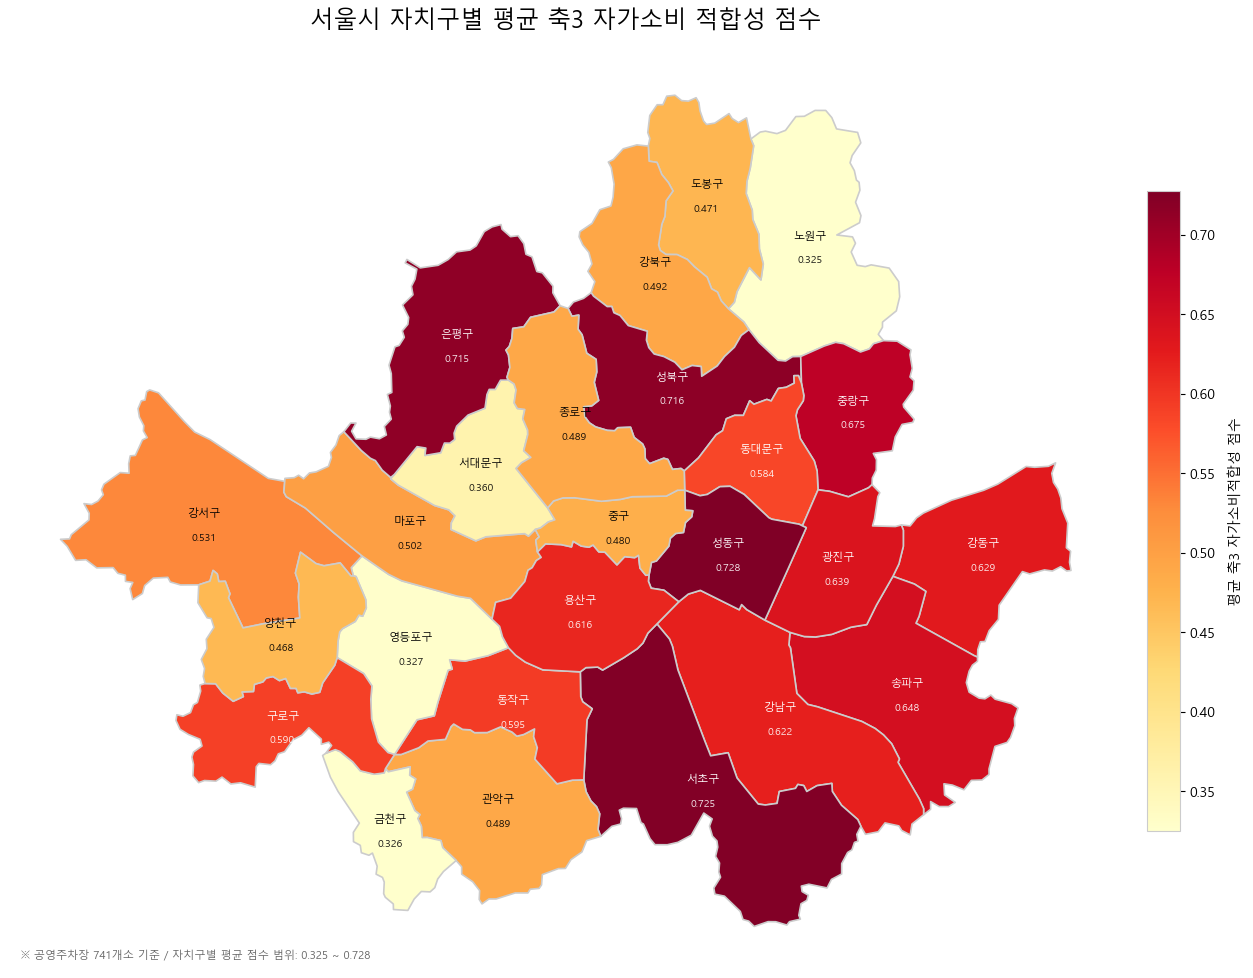

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_코로플레스.png


In [5]:
# ── 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

vmin = gu_score['avg_score'].min()
vmax = gu_score['avg_score'].max()
cmap = cm.get_cmap('YlOrRd')

geo.plot(
    column='avg_score',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#cccccc',
    linewidth=1.2,
    legend=False,
    vmin=vmin, vmax=vmax,
    missing_kwds={'color': '#eeeeee'}
)

# ── 구명 + 점수 라벨 ──────────────────────────────────
for _, row in geo.iterrows():
    if row.geometry is None or pd.isna(row['avg_score']):
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    score = row['avg_score']

    norm_val = (score - vmin) / (vmax - vmin)
    bg_color = cmap(norm_val)
    brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
    text_color = 'black' if brightness > 0.5 else 'white'

    ax.text(cx, cy + 0.003, row['name'],
            ha='center', va='center', fontproperties=font_prop,
            fontsize=8, color=text_color, fontweight='bold')
    ax.text(cx, cy - 0.005, f"{score:.3f}",
            ha='center', va='center', fontproperties=font_prop,
            fontsize=7.5, color=text_color, alpha=0.9)

# ── 컬러바 ────────────────────────────────────────────
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm   = cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.028, pad=0.02, shrink=0.7)
cbar.ax.tick_params(colors='black', labelsize=9)
cbar.outline.set_edgecolor('#cccccc')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black', fontproperties=font_prop)
cbar.set_label('평균 축3 자가소비적합성 점수', color='black',
               fontproperties=font_prop, fontsize=10, labelpad=10)

# ── 제목 & 주석 ───────────────────────────────────────
ax.set_title('서울시 자치구별 평균 축3 자가소비 적합성 점수',
             fontproperties=font_prop, fontsize=17, fontweight='bold',
             color='black', pad=18)

ax.annotate(
    f'※ 공영주차장 741개소 기준 / 자치구별 평균 점수 범위: {vmin:.3f} ~ {vmax:.3f}',
    xy=(0.01, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=8, color='#666666'
)

ax.set_axis_off()
plt.tight_layout(pad=1.5)

# ── 저장 ──────────────────────────────────────────────
save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_코로플레스.png'
plt.savefig(save_path, dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

### 시각화 — 자치구 코로플레스 + 상위 20개 주차장 버블 오버레이

자치구 평균(색상)과 상위 20개 개별 주차장(버블)을 동시에 표현하여
자치구 평균과 개별 입지의 역전 현상을 시각화한다.

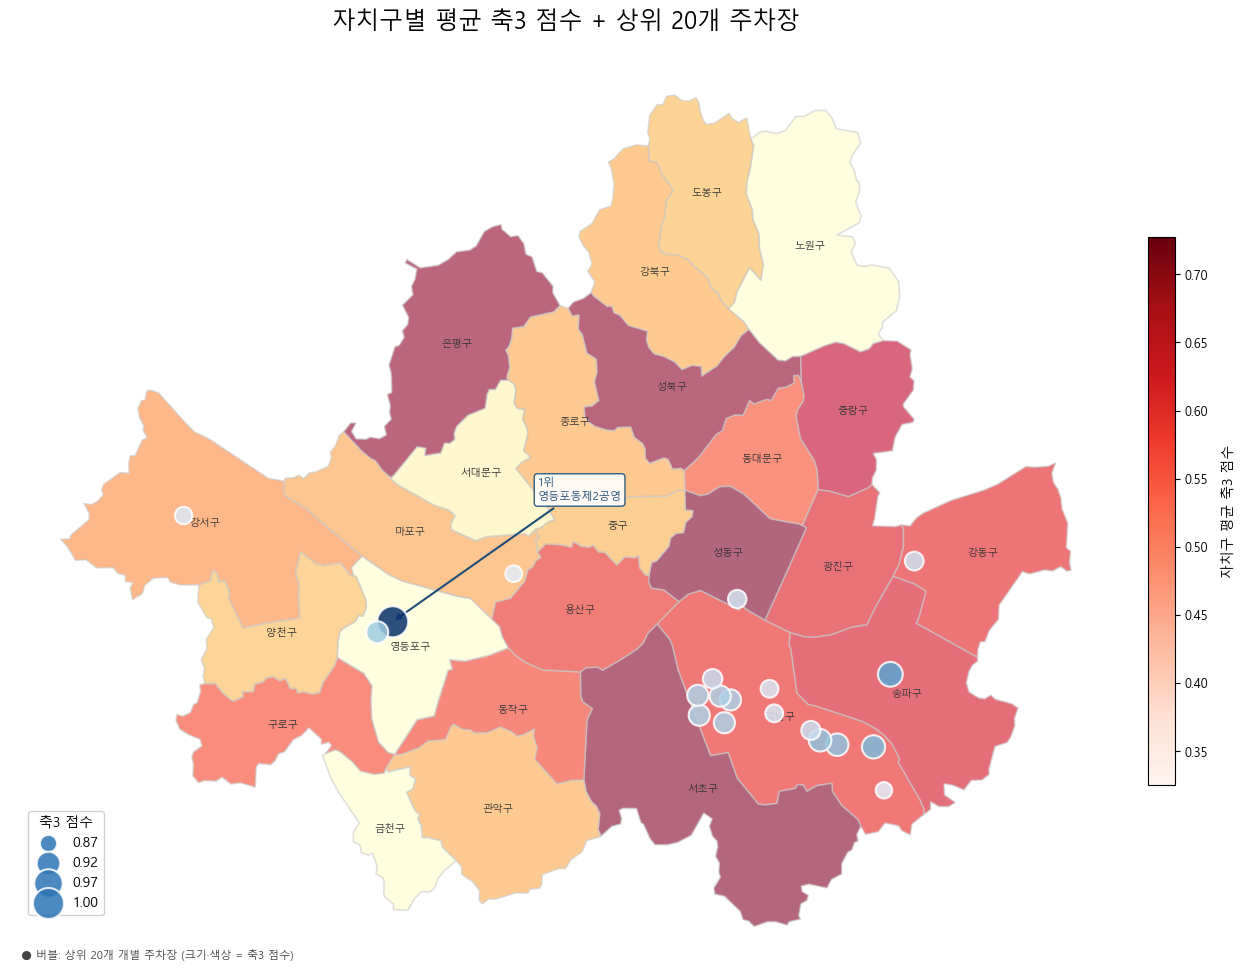

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_버블오버레이.png


In [6]:
# ── 버블오버레이 수정 ─────────────────────────────────
import numpy as np

top20 = df_result.nlargest(20, '축3_자가소비적합성').copy()

# 겹침 방지 jitter 추가
np.random.seed(42)
top20['lot_j'] = top20['lot'] + np.random.uniform(-0.008, 0.008, len(top20))
top20['lat_j'] = top20['lat'] + np.random.uniform(-0.008, 0.008, len(top20))

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

vmin = gu_score['avg_score'].min()
vmax = gu_score['avg_score'].max()
cmap_r = cm.get_cmap('YlOrRd')

# 자치구 코로플레스
geo.plot(
    column='avg_score',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#cccccc',
    linewidth=1.2,
    legend=False,
    vmin=vmin, vmax=vmax,
    missing_kwds={'color': '#eeeeee'},
    alpha=0.6
)

# 구명 라벨
for _, row in geo.iterrows():
    if row.geometry is None or pd.isna(row['avg_score']):
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, row['name'],
            ha='center', va='center', fontproperties=font_prop,
            fontsize=7.5, color='#333333', fontweight='bold')

# 상위 20개 버블 — 크기 + 색상 동시 표현
sizes = (top20['축3_자가소비적합성'] - 0.85) / (1.0 - 0.85) * 400 + 100

scatter = ax.scatter(
    top20['lot_j'], top20['lat_j'],
    s=sizes,
    c=top20['축3_자가소비적합성'],
    cmap='Blues',
    vmin=0.85, vmax=1.0,
    edgecolors='white',
    linewidths=1.5,
    alpha=0.85,
    zorder=5
)

# 버블 크기 범례
for score, label in [(0.87, '0.87'), (0.92, '0.92'), (0.97, '0.97'), (1.00, '1.00')]:
    s = (score - 0.85) / (1.0 - 0.85) * 400 + 100
    ax.scatter([], [], s=s, c='#2E75B6', alpha=0.85,
               edgecolors='white', linewidths=1.5, label=label)

legend = ax.legend(
    title='축3 점수', title_fontproperties=font_prop,
    prop=font_prop, fontsize=8,
    loc='lower left', bbox_to_anchor=(0.01, 0.05) ,framealpha=0.9,
    edgecolor='#CCCCCC', facecolor='white',
    scatterpoints=1
)

# 1위 주차장 표시
top1 = top20.iloc[0]
ax.annotate(
    f"1위\n{top1['pklt_nm']}",
    xy=(top1['lot_j'], top1['lat_j']),
    xytext=(top1['lot_j'] + 0.06, top1['lat_j'] + 0.04),
    fontproperties=font_prop,
    fontsize=8, color='#1F4E79', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1F4E79', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor='#1F4E79', alpha=0.9)
)

# 컬러바 (자치구 평균)
norm_r = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm_r   = cm.ScalarMappable(cmap='Reds', norm=norm_r)
sm_r.set_array([])
cbar = fig.colorbar(sm_r, ax=ax, fraction=0.028, pad=0.02, shrink=0.6)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('자치구 평균 축3 점수', fontproperties=font_prop,
               fontsize=10, labelpad=10)

ax.set_title('자치구별 평균 축3 점수 + 상위 20개 주차장',
             fontproperties=font_prop, fontsize=17,
             fontweight='bold', color='black', pad=18)
ax.annotate(
    '● 버블: 상위 20개 개별 주차장 (크기·색상 = 축3 점수)',
    xy=(0.01, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=8, color='#444444'
)

ax.set_axis_off()
plt.tight_layout(pad=1.5)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\자치구별_축3_버블오버레이.png'
plt.savefig(save_path, dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

### 시각화 — 741개 개별 주차장 버블 지도 (자치구 경계 포함)

741개 공영주차장 전체를 축3 점수에 따라 색상과 크기로 표현하여
개별 입지의 공간적 분포를 확인한다.

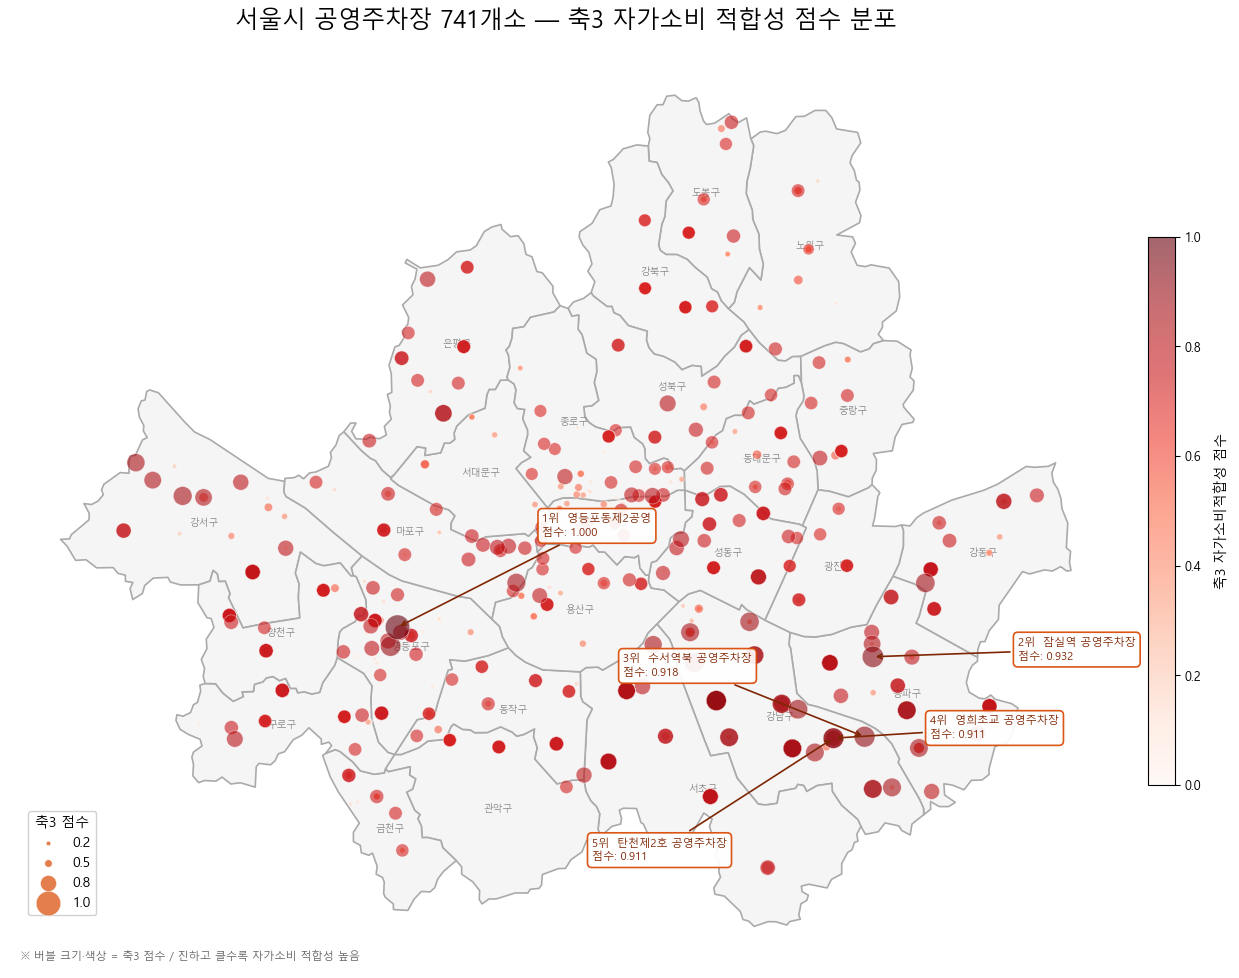

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\개별주차장_741_버블지도.png


In [7]:
# ── 741개 버블지도 수정 ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 자치구 경계 배경
geo.plot(
    ax=ax,
    color='#F5F5F5',
    edgecolor='#AAAAAA',
    linewidth=1.2
)

# 구명 라벨
for _, row in geo.iterrows():
    if row.geometry is None:
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, row['name'],
            ha='center', va='center', fontproperties=font_prop,
            fontsize=7, color='#888888', fontweight='bold')

# 741개 버블 — 낮은 점수 먼저 그리기
df_sorted = df_result.sort_values('축3_자가소비적합성', ascending=True)
sizes_all = df_sorted['축3_자가소비적합성'] ** 4 * 300 + 10  # 비선형 크기 차이 강조

scatter = ax.scatter(
    df_sorted['lot'],
    df_sorted['lat'],
    s=sizes_all,
    c=df_sorted['축3_자가소비적합성'],
    cmap='Reds',
    vmin=0, vmax=1,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.6,
    zorder=5
)

# 버블 크기 범례
for score, label in [(0.2, '0.2'), (0.5, '0.5'), (0.8, '0.8'), (1.0, '1.0')]:
    s = score ** 4 * 300 + 10
    ax.scatter([], [], s=s, c='#D94701', alpha=0.7,
               edgecolors='white', linewidths=0.4, label=label)

ax.legend(
    title='축3 점수', title_fontproperties=font_prop,
    prop=font_prop, fontsize=8,
    loc='lower left', bbox_to_anchor=(0.01, 0.05), framealpha=0.9,
    edgecolor='#CCCCCC', facecolor='white',
    scatterpoints=1
)

# 상위 5개 주차장 박스 라벨
top5 = df_result.nlargest(5, '축3_자가소비적합성')
offsets = [
    (0.06, 0.03), 
    (0.06, -0.0009), 
    (-0.10, 0.02), 
    (0.04, 0.00009), 
    (-0.10, -0.04),
]
for i, ((_, row), (dx, dy)) in enumerate(zip(top5.iterrows(), offsets)):
    ax.annotate(
        f"{i+1}위  {row['pklt_nm']}\n점수: {row['축3_자가소비적합성']:.3f}",
        xy=(row['lot'], row['lat']),
        xytext=(row['lot'] + dx, row['lat'] + dy),
        fontproperties=font_prop,
        fontsize=8, color='#7F2704', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#7F2704', lw=1.2),
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='#D94701',
            alpha=0.92,
            linewidth=1.2
        ),
        zorder=7
    )

# 컬러바
cbar = fig.colorbar(scatter, ax=ax, fraction=0.028, pad=0.02, shrink=0.6)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('축3 자가소비적합성 점수', fontproperties=font_prop,
               fontsize=10, labelpad=10)

ax.set_title('서울시 공영주차장 741개소 — 축3 자가소비 적합성 점수 분포',
             fontproperties=font_prop, fontsize=17,
             fontweight='bold', color='black', pad=18)
ax.annotate(
    '※ 버블 크기·색상 = 축3 점수 / 진하고 클수록 자가소비 적합성 높음',
    xy=(0.01, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=8, color='#666666'
)

ax.set_axis_off()
plt.tight_layout(pad=1.5)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\개별주차장_741_버블지도.png'
plt.savefig(save_path, dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

---
## 피피티 2페이지 — 시각화 자료 & 인사이트

> 시각화 자료 1 — 서울시 공영주차장 741개소 축3 점수 지도

**버블 크기**: 반경 200m EV 충전소 수 (EV 수요 밀도)
**버블 색상**: 축3 자가소비적합성 점수 (진할수록 높음)

> 시각화 자료 2 — 4분면 산점도 


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


3 [-0.22371833  0.64716314]
4 [-0.01772673 -0.38301924]


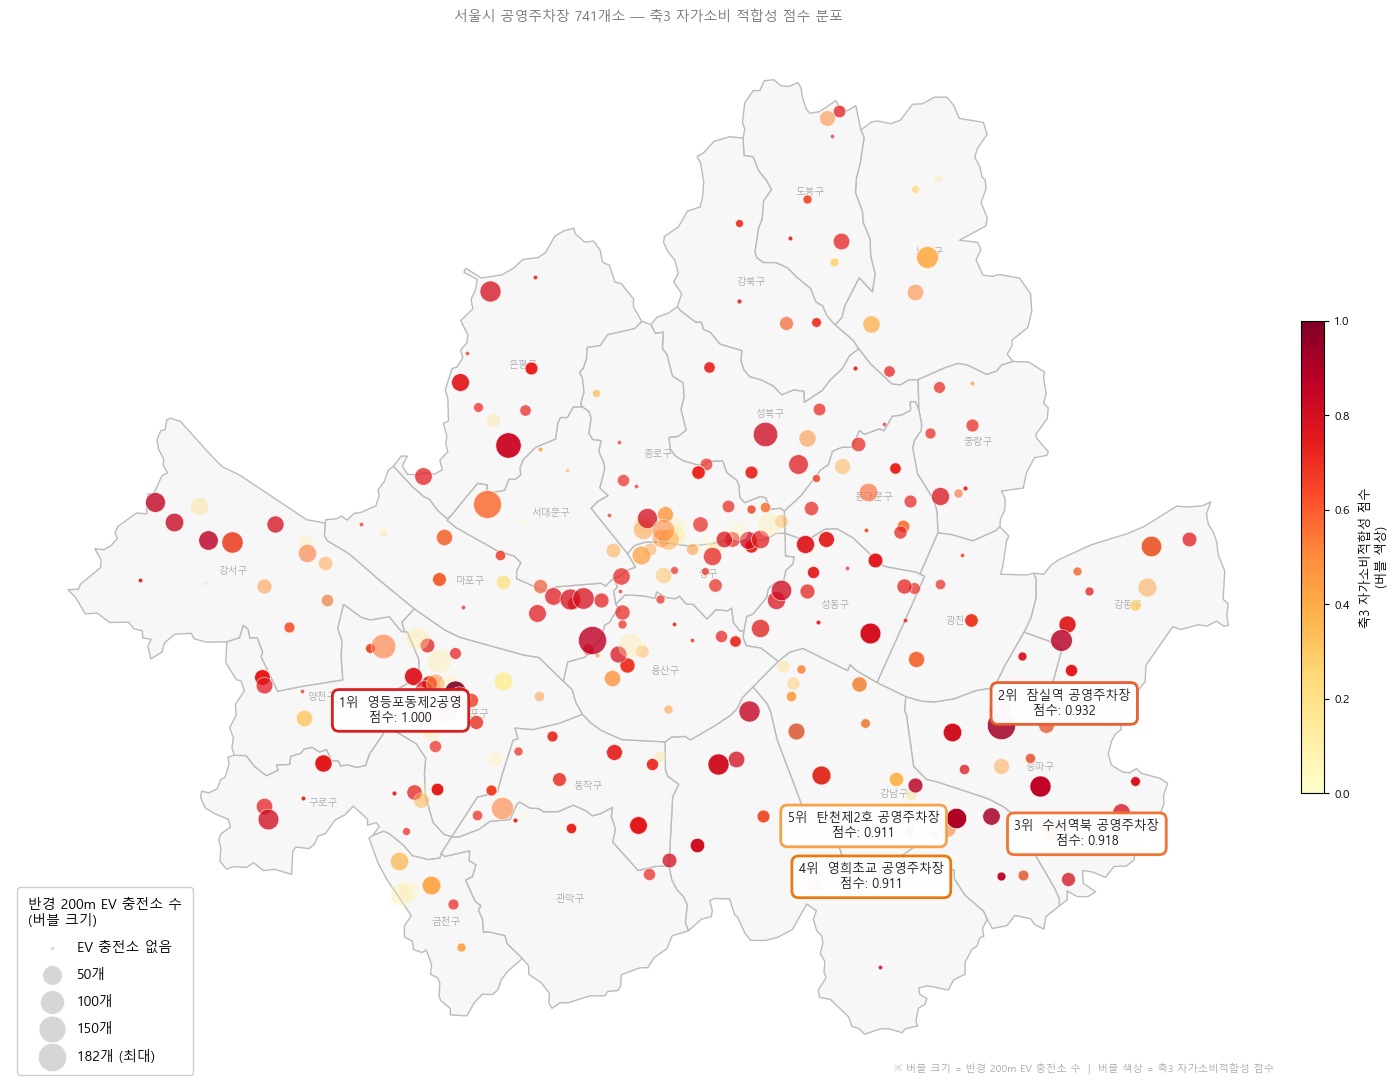

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\개별주차장_741_버블지도_ev200m.png


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────
import platform
system = platform.system()
if system == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif system == 'Darwin':
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_bold = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = gpd.read_file(requests.get(url).text)

# ── 버블 크기: ev_200m 기반 ───────────────────────────
# ev_200m 최댓값 기준 정규화 후 크기 결정
ev200_max = df_result['ev_200m'].max()

def get_size_ev200(ev200):
    if ev200 == 0:
        return 8           # 최소 점
    ratio = ev200 / ev200_max
    return ratio ** 0.6 * 400 + 15   # 비선형 강조

df_sorted = df_result.sort_values('축3_자가소비적합성', ascending=True).copy()
df_sorted['bubble_size'] = df_sorted['ev_200m'].apply(get_size_ev200)

# ── 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 자치구 경계
geo.plot(ax=ax, color='#F7F7F7', edgecolor='#BBBBBB', linewidth=1.0)

# 구명 라벨
for _, row in geo.iterrows():
    if row.geometry is None:
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, row['name'],
            ha='center', va='center',
            fontproperties=font_prop,
            fontsize=7, color='#AAAAAA')

# ── 버블 (색상=축3점수, 크기=ev_200m) ────────────────
cmap_obj = cm.get_cmap('YlOrRd')
norm_obj  = mcolors.Normalize(vmin=0, vmax=1)

# ev_200m=0인 주차장 먼저 (뒤로)
df_zero    = df_sorted[df_sorted['ev_200m'] == 0]
df_nonzero = df_sorted[df_sorted['ev_200m'] >  0].sort_values('ev_200m')

for df_part, zorder, lw in [(df_zero, 3, 0.2), (df_nonzero, 5, 0.5)]:
    colors = [cmap_obj(norm_obj(s)) for s in df_part['축3_자가소비적합성']]
    alphas = [0.25 + s * 0.65 for s in df_part['축3_자가소비적합성']]
    for (_, row), color, alpha in zip(df_part.iterrows(), colors, alphas):
        ax.scatter(
            row['lot'], row['lat'],
            s=row['bubble_size'],
            color=color,
            edgecolors='white',
            linewidths=lw,
            alpha=alpha,
            zorder=zorder
        )

# 컬러바용 dummy scatter
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm_obj)
sm.set_array([])

# ── 상위 5개 라벨 ─────────────────────────────────────
top5 = df_result.nlargest(5, '축3_자가소비적합성').reset_index(drop=True)
rank_colors = ['#D7191C', '#E85A2A', '#F07030', '#E8760A', '#F5A040']

from adjustText import adjust_text
texts = []
for i, (_, row) in enumerate(top5.iterrows()):
    t = ax.text(
        row['lot'], row['lat'],
        f"{i+1}위  {row['pklt_nm']}\n점수: {row['축3_자가소비적합성']:.3f}",
        fontproperties=font_bold,
        fontsize=9,
        color='#1A1A1A',
        ha='center', va='center',
        bbox=dict(
            boxstyle='round,pad=0.55',
            facecolor='white',
            edgecolor=rank_colors[i],
            linewidth=2.0,
            alpha=0.97
        ),
        zorder=9
    )
    texts.append(t)

adjust_text(
    texts, ax=ax,
    expand_points=(2.5, 2.5),
    expand_text=(1.5, 1.5),
    force_points=(0.8, 0.8),
    arrowprops=dict(arrowstyle='-', color='#BBBBBB', lw=1.0)
)

# ── 버블 크기 범례 (ev_200m 기준) ─────────────────────
import matplotlib.patches as mpatches

legend_ev = [
    (0,   'EV 충전소 없음'),
    (50,  '50개'),
    (100, '100개'),
    (150, '150개'),
    (182, '182개 (최대)'),
]

legend_handles = []
for ev, label in legend_ev:
    size = get_size_ev200(ev)
    h = ax.scatter([], [], s=size,
                   color='#CCCCCC',
                   edgecolors='white', linewidths=0.5,
                   alpha=0.8, label=label)
    legend_handles.append(h)

leg = ax.legend(
    handles=legend_handles,
    title='반경 200m EV 충전소 수\n(버블 크기)',
    title_fontproperties=font_bold,
    prop=font_prop,
    fontsize=8.5,
    loc='lower left',
    framealpha=0.95,
    edgecolor='#CCCCCC',
    facecolor='white',
    scatterpoints=1,
    labelspacing=1.0,
    borderpad=0.8
)

# ── 컬러바 (축3 점수) ─────────────────────────────────
cbar = fig.colorbar(sm, ax=ax, fraction=0.022, pad=0.01, shrink=0.45)
cbar.ax.tick_params(labelsize=8.5)
cbar.set_label('축3 자가소비적합성 점수\n(버블 색상)',
               fontproperties=font_prop, fontsize=9, labelpad=8)

# ── 제목 & 주석 ───────────────────────────────────────
ax.set_title('서울시 공영주차장 741개소 — 축3 자가소비 적합성 점수 분포',
             fontproperties=font_prop, fontsize=10,
             color='#777777', pad=8)

ax.annotate(
    '※ 버블 크기 = 반경 200m EV 충전소 수  |  버블 색상 = 축3 자가소비적합성 점수',
    xy=(0.99, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=7.5,
    color='#AAAAAA', ha='right'
)

ax.set_axis_off()
plt.tight_layout(pad=1.0)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\개별주차장_741_버블지도_ev200m.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

3 [-0.84190599 -0.48350086]
4 [ 0.90563879 -0.63981053]


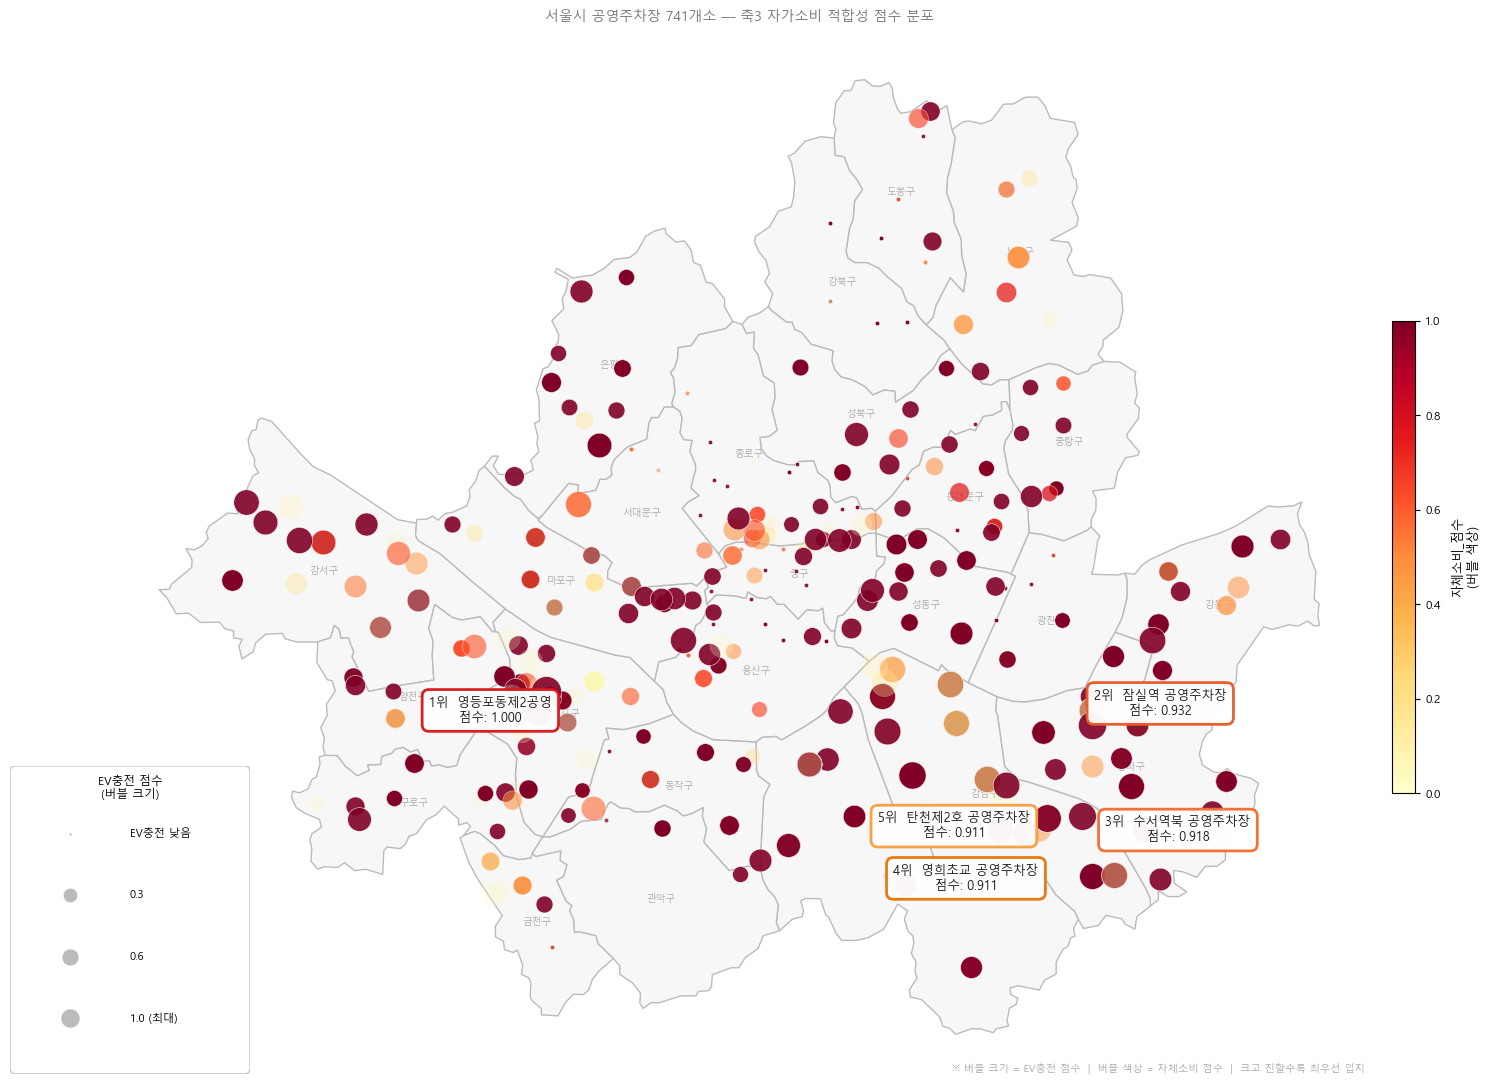

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\버블지도_EV크기_자체소비색상.png


In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────
import platform
system = platform.system()
if system == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif system == 'Darwin':
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_bold = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = gpd.read_file(requests.get(url).text)

# ── 버블 크기: EV충전_점수_norm 기반 ─────────────────
ev_max = df_result['EV충전_점수_norm'].max()

def get_size_ev(ev):
    if ev <= 0.05:
        return 10
    ratio = ev / ev_max
    return ratio ** 0.5 * 450 + 15

# ── 투명도: 자체소비_점수 기반 ───────────────────────
def get_alpha(score):
    return 0.2 + score * 0.7

df_sorted = df_result.sort_values('EV충전_점수_norm', ascending=True).copy()
df_sorted['bubble_size']  = df_sorted['EV충전_점수_norm'].apply(get_size_ev)
df_sorted['bubble_alpha'] = df_sorted['자체소비_점수'].apply(get_alpha)

# ── 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 자치구 경계
geo.plot(ax=ax, color='#F7F7F7', edgecolor='#BBBBBB', linewidth=1.0)

# 구명 라벨
for _, row in geo.iterrows():
    if row.geometry is None:
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, row['name'],
            ha='center', va='center',
            fontproperties=font_prop,
            fontsize=7, color='#AAAAAA')

# ── 버블 (색상=자체소비, 크기=EV충전) ────────────────
cmap_obj = cm.get_cmap('YlOrRd')
norm_obj  = mcolors.Normalize(vmin=0, vmax=1)

for _, row in df_sorted.iterrows():
    color = cmap_obj(norm_obj(row['자체소비_점수']))
    ax.scatter(
        row['lot'], row['lat'],
        s=row['bubble_size'],
        color=color,
        edgecolors='white',
        linewidths=0.4,
        alpha=row['bubble_alpha'],
        zorder=5
    )

# 컬러바용 dummy scatter
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm_obj)
sm.set_array([])

# ── 상위 5개 라벨 ─────────────────────────────────────
top5 = df_result.nlargest(5, '축3_자가소비적합성').reset_index(drop=True)
rank_colors = ['#D7191C', '#E85A2A', '#F07030', '#E8760A', '#F5A040']

from adjustText import adjust_text
texts = []
for i, (_, row) in enumerate(top5.iterrows()):
    t = ax.text(
        row['lot'], row['lat'],
        f"{i+1}위  {row['pklt_nm']}\n점수: {row['축3_자가소비적합성']:.3f}",
        fontproperties=font_bold,
        fontsize=9,
        color='#1A1A1A',
        ha='center', va='center',
        bbox=dict(
            boxstyle='round,pad=0.55',
            facecolor='white',
            edgecolor=rank_colors[i],
            linewidth=2.0,
            alpha=0.97
        ),
        zorder=9
    )
    texts.append(t)

adjust_text(
    texts, ax=ax,
    expand_points=(2.5, 2.5),
    expand_text=(1.5, 1.5),
    force_points=(0.8, 0.8),
)

# ── 버블 크기 범례 (EV충전 기준) ─────────────────────
import matplotlib.patches as mpatches

legend_ev = [
    (0.05, 'EV충전 낮음'),
    (0.3,  '0.3'),
    (0.6,  '0.6'),
    (1.0,  '1.0 (최대)'),
]

legend_x = 0.01
legend_y = 0.30
box_w, box_h = 0.16, 0.28

ax_rect = fig.add_axes([legend_x, legend_y - box_h, box_w, box_h])
ax_rect.set_axis_off()
ax_rect.set_facecolor('white')

ax_rect.text(0.5, 0.97, 'EV충전 점수\n(버블 크기)', ha='center', va='top',
             fontproperties=font_bold, fontsize=8.5,
             transform=ax_rect.transAxes)

for j, (ev, label) in enumerate(legend_ev):
    y_pos = 0.78 - j * 0.20
    size  = get_size_ev(ev)
    ax_rect.scatter([0.25], [y_pos], s=size * 0.4,
                    color='#AAAAAA', alpha=0.8,
                    edgecolors='white', linewidths=0.4,
                    transform=ax_rect.transAxes, clip_on=False)
    ax_rect.text(0.50, y_pos, label, ha='left', va='center',
                 fontproperties=font_prop, fontsize=8,
                 transform=ax_rect.transAxes)

rect = mpatches.FancyBboxPatch(
    (0.02, 0.02), 0.96, 0.96,
    boxstyle='round,pad=0.02',
    linewidth=1.2, edgecolor='#CCCCCC',
    facecolor='white', transform=ax_rect.transAxes, zorder=0
)
ax_rect.add_patch(rect)

# ── 컬러바 (자체소비 점수) ───────────────────────────
cbar = fig.colorbar(sm, ax=ax, fraction=0.022, pad=0.01, shrink=0.45)
cbar.ax.tick_params(labelsize=8.5)
cbar.set_label('자체소비_점수\n(버블 색상)',
               fontproperties=font_prop, fontsize=9, labelpad=8)

# ── 제목 & 주석 ───────────────────────────────────────
ax.set_title('서울시 공영주차장 741개소 — 축3 자가소비 적합성 점수 분포',
             fontproperties=font_prop, fontsize=10,
             color='#777777', pad=8)

ax.annotate(
    '※ 버블 크기 = EV충전 점수  |  버블 색상 = 자체소비 점수  |  크고 진할수록 최우선 입지',
    xy=(0.99, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=7.5,
    color='#AAAAAA', ha='right'
)

ax.set_axis_off()
plt.tight_layout(pad=1.0)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\버블지도_EV크기_자체소비색상.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

## 버블지도 — EV충전점수(버블 크기) × 축3 자가소비적합성(색상)

- 버블 크기: EV충전점수 (인프라 + 수요 복합)
- 버블 색상: 축3 자가소비적합성 점수 (자체소비 + EV충전 종합)
- Top5: 축3 점수 기준 상위 5개 주차장 라벨 표시

3 [ 0.19389592 -0.11861565]
4 [-0.02836345  0.15595971]


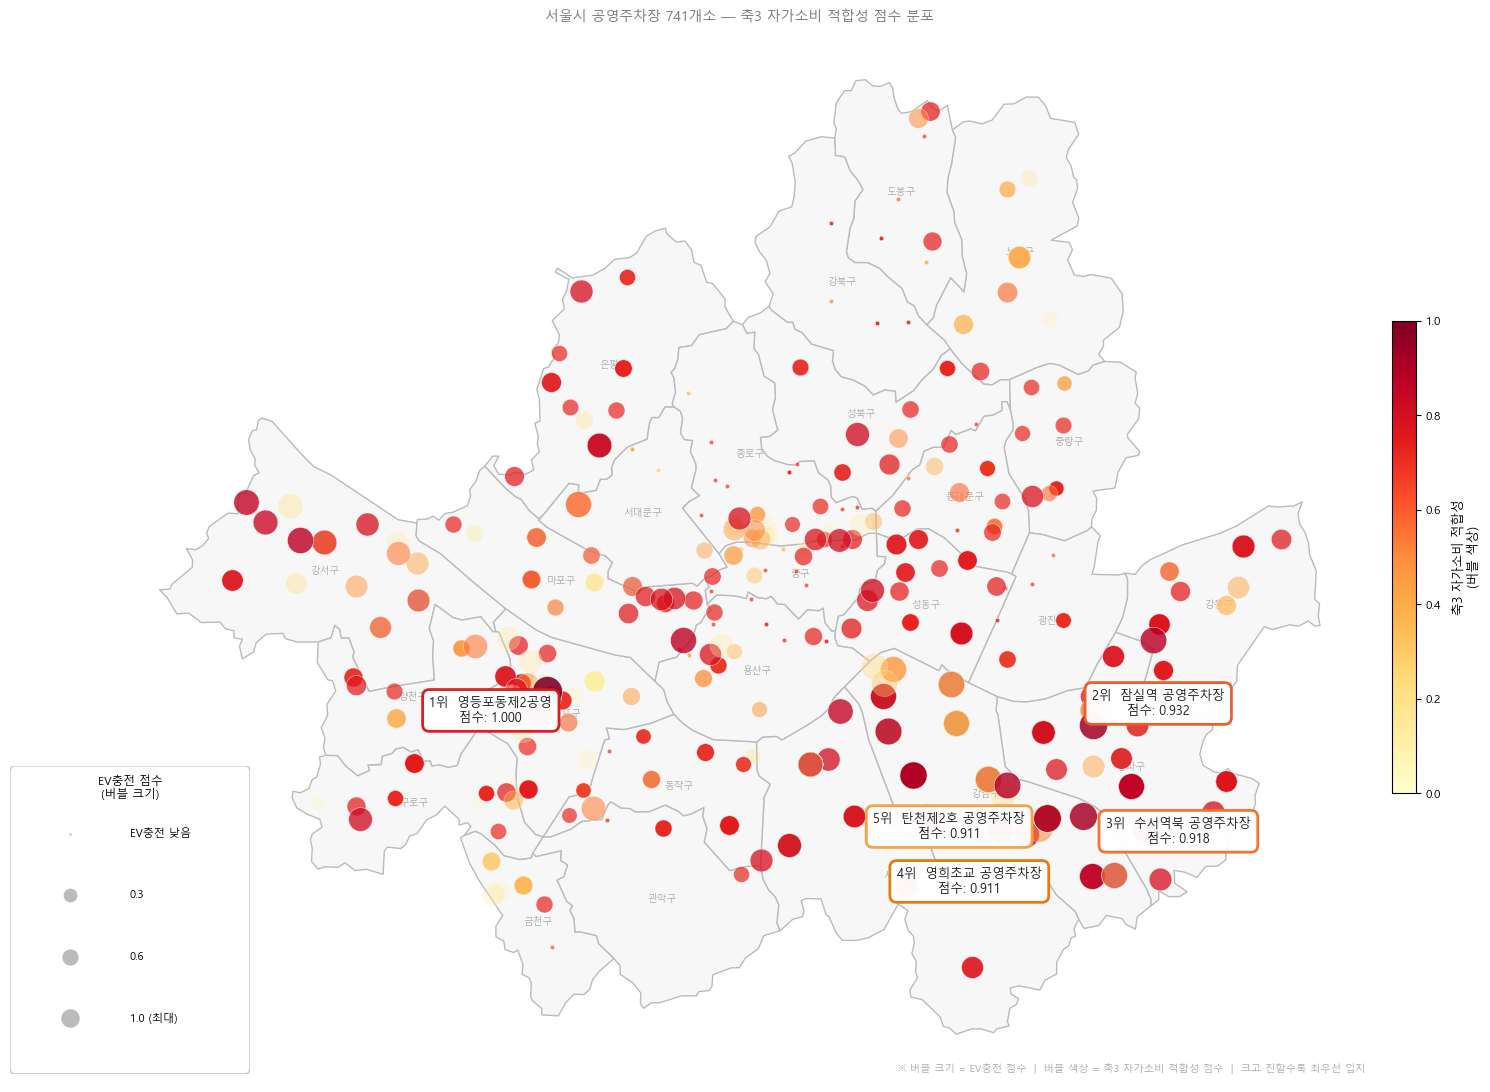

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\버블지도_EV크기_축3색상.png


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────
import platform
system = platform.system()
if system == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif system == 'Darwin':
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_bold = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = gpd.read_file(requests.get(url).text)

# ── 버블 크기: EV충전_점수_norm 기반 ─────────────────
ev_max = df_result['EV충전_점수_norm'].max()

def get_size_ev(ev):
    if ev <= 0.05:
        return 10
    ratio = ev / ev_max
    return ratio ** 0.5 * 450 + 15

# ── 투명도: 축3_자가소비적합성 기반 ─────────────────
def get_alpha(score):
    return 0.2 + score * 0.7

df_sorted = df_result.sort_values('EV충전_점수_norm', ascending=True).copy()
df_sorted['bubble_size']  = df_sorted['EV충전_점수_norm'].apply(get_size_ev)
df_sorted['bubble_alpha'] = df_sorted['축3_자가소비적합성'].apply(get_alpha)  # ← 변경

# ── 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 자치구 경계
geo.plot(ax=ax, color='#F7F7F7', edgecolor='#BBBBBB', linewidth=1.0)

# 구명 라벨
for _, row in geo.iterrows():
    if row.geometry is None:
        continue
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, row['name'],
            ha='center', va='center',
            fontproperties=font_prop,
            fontsize=7, color='#AAAAAA')

# ── 버블 (색상=축3점수, 크기=EV충전) ─────────────────
cmap_obj = cm.get_cmap('YlOrRd')
norm_obj  = mcolors.Normalize(vmin=0, vmax=1)

for _, row in df_sorted.iterrows():
    color = cmap_obj(norm_obj(row['축3_자가소비적합성']))  # ← 변경
    ax.scatter(
        row['lot'], row['lat'],
        s=row['bubble_size'],
        color=color,
        edgecolors='white',
        linewidths=0.4,
        alpha=row['bubble_alpha'],
        zorder=5
    )

# 컬러바용 dummy scatter
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm_obj)
sm.set_array([])

# ── 상위 5개 라벨 ─────────────────────────────────────
top5 = df_result.nlargest(5, '축3_자가소비적합성').reset_index(drop=True)
rank_colors = ['#D7191C', '#E85A2A', '#F07030', '#E8760A', '#F5A040']

from adjustText import adjust_text
texts = []
for i, (_, row) in enumerate(top5.iterrows()):
    t = ax.text(
        row['lot'], row['lat'],
        f"{i+1}위  {row['pklt_nm']}\n점수: {row['축3_자가소비적합성']:.3f}",
        fontproperties=font_bold,
        fontsize=9,
        color='#1A1A1A',
        ha='center', va='center',
        bbox=dict(
            boxstyle='round,pad=0.55',
            facecolor='white',
            edgecolor=rank_colors[i],
            linewidth=2.0,
            alpha=0.97
        ),
        zorder=9
    )
    texts.append(t)

adjust_text(
    texts, ax=ax,
    expand_points=(2.5, 2.5),
    expand_text=(1.5, 1.5),
    force_points=(0.8, 0.8),
)

# ── 버블 크기 범례 (EV충전 기준) ─────────────────────
import matplotlib.patches as mpatches

legend_ev = [
    (0.05, 'EV충전 낮음'),
    (0.3,  '0.3'),
    (0.6,  '0.6'),
    (1.0,  '1.0 (최대)'),
]

legend_x = 0.01
legend_y = 0.30
box_w, box_h = 0.16, 0.28

ax_rect = fig.add_axes([legend_x, legend_y - box_h, box_w, box_h])
ax_rect.set_axis_off()
ax_rect.set_facecolor('white')

ax_rect.text(0.5, 0.97, 'EV충전 점수\n(버블 크기)', ha='center', va='top',
             fontproperties=font_bold, fontsize=8.5,
             transform=ax_rect.transAxes)

for j, (ev, label) in enumerate(legend_ev):
    y_pos = 0.78 - j * 0.20
    size  = get_size_ev(ev)
    ax_rect.scatter([0.25], [y_pos], s=size * 0.4,
                    color='#AAAAAA', alpha=0.8,
                    edgecolors='white', linewidths=0.4,
                    transform=ax_rect.transAxes, clip_on=False)
    ax_rect.text(0.50, y_pos, label, ha='left', va='center',
                 fontproperties=font_prop, fontsize=8,
                 transform=ax_rect.transAxes)

rect = mpatches.FancyBboxPatch(
    (0.02, 0.02), 0.96, 0.96,
    boxstyle='round,pad=0.02',
    linewidth=1.2, edgecolor='#CCCCCC',
    facecolor='white', transform=ax_rect.transAxes, zorder=0
)
ax_rect.add_patch(rect)

# ── 컬러바 (축3 점수) ────────────────────────────────
cbar = fig.colorbar(sm, ax=ax, fraction=0.022, pad=0.01, shrink=0.45)
cbar.ax.tick_params(labelsize=8.5)
cbar.set_label('축3 자가소비 적합성\n(버블 색상)',          # ← 변경
               fontproperties=font_prop, fontsize=9, labelpad=8)

# ── 제목 & 주석 ───────────────────────────────────────
ax.set_title('서울시 공영주차장 741개소 — 축3 자가소비 적합성 점수 분포',
             fontproperties=font_prop, fontsize=10,
             color='#777777', pad=8)

ax.annotate(
    '※ 버블 크기 = EV충전 점수  |  버블 색상 = 축3 자가소비 적합성 점수  |  크고 진할수록 최우선 입지',  # ← 변경
    xy=(0.99, 0.01), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=7.5,
    color='#AAAAAA', ha='right'
)

ax.set_axis_off()
plt.tight_layout(pad=1.0)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\버블지도_EV크기_축3색상.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")

## 버블지도 해석 — 축3 자가소비 적합성 점수 분포

### 시각화 설계
- 버블 크기: EV충전 점수 (인프라 + 수요 복합 잠재력)
- 버블 색상: 축3 자가소비 적합성 점수 (자체소비 + EV충전 종합)
- 해석 원칙: 버블이 크고 색이 진할수록 태양광 캐노피 최우선 입지

### 구역별 패턴 요약
| 구역 | 버블(EV충전 잠재력) | 색상(축3 종합) | 해석 |
|------|------------------|--------------|------|
| 서남권(영등포·양천·강서) | 대형 다수 | 진함 | EV충전 잠재력·종합 적합성 동시 우수, 1위 배출 |
| 동남권(송파·강남·강동) | 중~대형 | 진함 | 종합 적합성 안정적, 2~5위 집중 |
| 도심축(마포·용산·중구) | 소~중형 | 진함 | 자체소비 조건 우수, EV충전 잠재력 부족 |
| 북부·외곽(도봉·노원·강북) | 소형 | 연함 | 두 조건 모두 낮음 |

### 핵심 인사이트
버블 크고 색 진한 조합은 서남권·동남권에 집중되나,
동일 구역 내에서도 버블 크기와 색상이 혼재하는 경향 존재
→ 구역 단위 해석만으로는 개별 입지 선별 불가 → 개별 단위 정밀 분석 필요

In [2]:
report_text = """
[버블지도 해석 — 축3 자가소비 적합성 점수 분포]

■ 시각화 설계
버블 크기는 EV충전 잠재력(인프라·수요 복합), 버블 색상은 축3 자가소비 적합성 점수(자체소비+EV충전 종합)를
각각 나타내며, 버블이 크고 색이 진할수록 태양광 캐노피 최우선 입지에 해당한다.

■ 구역별 패턴

① 서남권(영등포·양천·강서)
EV충전 잠재력이 높은 대형 버블과 축3 점수가 높은 진한 색상의 조합이 밀집되어 있다.
두 조건이 동시에 우수한 주차장이 집중된 구역으로, 최고 점수 1위가 이 구역에서 배출되었다.
단, 구역 내 일부 대형 버블의 색상이 연한 경우가 관찰되어 개별 선별의 필요성이 존재한다.

② 동남권(송파·강남·강동)
중~대형 버블과 진한 색상이 안정적으로 분포한다.
축3 종합 적합성 측면에서 가장 균일한 고점 분포를 보이며, 2~5위가 이 구역에 집중되었다.

③ 도심축(마포·용산·중구)
색상은 진하나 버블 크기가 상대적으로 작다.
자체소비 조건은 우수하지만 EV충전 잠재력이 부족한 구조로,
EV 인프라 확충 시 즉시 상위권 도약이 가능한 미래형 투자 구간에 해당한다.

④ 북부·외곽(도봉·노원·강북)
버블이 작고 색상이 연하여 EV충전 잠재력과 종합 적합성 모두 낮은 구역으로 명확히 구분된다.

■ 핵심 인사이트
EV충전 잠재력과 종합 적합성이 동시에 높은 조합은 서남권·동남권에 집중되어 있다.
그러나 동일 구역 내에서도 버블 크기와 색상이 혼재하는 경향이 관찰되며,
이는 구역 단위 해석만으로는 개별 입지를 정확히 선별하기 어려움을 시사한다.
따라서 다음 단계에서 개별 주차장 단위의 정밀 분석이 요구된다.
"""

print(report_text)


[버블지도 해석 — 축3 자가소비 적합성 점수 분포]

■ 시각화 설계
버블 크기는 EV충전 잠재력(인프라·수요 복합), 버블 색상은 축3 자가소비 적합성 점수(자체소비+EV충전 종합)를
각각 나타내며, 버블이 크고 색이 진할수록 태양광 캐노피 최우선 입지에 해당한다.

■ 구역별 패턴

① 서남권(영등포·양천·강서)
EV충전 잠재력이 높은 대형 버블과 축3 점수가 높은 진한 색상의 조합이 밀집되어 있다.
두 조건이 동시에 우수한 주차장이 집중된 구역으로, 최고 점수 1위가 이 구역에서 배출되었다.
단, 구역 내 일부 대형 버블의 색상이 연한 경우가 관찰되어 개별 선별의 필요성이 존재한다.

② 동남권(송파·강남·강동)
중~대형 버블과 진한 색상이 안정적으로 분포한다.
축3 종합 적합성 측면에서 가장 균일한 고점 분포를 보이며, 2~5위가 이 구역에 집중되었다.

③ 도심축(마포·용산·중구)
색상은 진하나 버블 크기가 상대적으로 작다.
자체소비 조건은 우수하지만 EV충전 잠재력이 부족한 구조로,
EV 인프라 확충 시 즉시 상위권 도약이 가능한 미래형 투자 구간에 해당한다.

④ 북부·외곽(도봉·노원·강북)
버블이 작고 색상이 연하여 EV충전 잠재력과 종합 적합성 모두 낮은 구역으로 명확히 구분된다.

■ 핵심 인사이트
EV충전 잠재력과 종합 적합성이 동시에 높은 조합은 서남권·동남권에 집중되어 있다.
그러나 동일 구역 내에서도 버블 크기와 색상이 혼재하는 경향이 관찰되며,
이는 구역 단위 해석만으로는 개별 입지를 정확히 선별하기 어려움을 시사한다.
따라서 다음 단계에서 개별 주차장 단위의 정밀 분석이 요구된다.



### 구역 단위 개별 주차장 점수 확인

In [2]:
# 도심축 실제 확인
도심축_구 = ['마포구', '용산구', '중구']
subset = df_result[df_result['자치구'].isin(도심축_구)]
print(f"자체소비 평균: {subset['자체소비_점수'].mean():.3f}")
print(f"EV충전 평균:   {subset['EV충전_점수_norm'].mean():.3f}")
print(f"자체소비 std:  {subset['자체소비_점수'].std():.3f}")
print(f"EV충전 std:    {subset['EV충전_점수_norm'].std():.3f}")

자체소비 평균: 0.708
EV충전 평균:   0.105
자체소비 std:  0.353
EV충전 std:    0.091


**도심축(마포,용산,중구)** 

- 자체소비 평균 0.708 → 서울 전체 평균(0.670)보다 높음
- EV충전 평균 0.105 → 서울 전체 평균(0.199)의 절반 수준
- 자체소비 std 0.353 → 분포가 넓음 (골고루 퍼져있음)
- EV충전 std 0.091 → 분포가 좁음 (낮은 쪽에 몰려있음)

>"자체소비 조건은 갖췄지만 EV 인프라가 절대적으로 부족"
자체소비 평균 0.708(서울 평균 이상)로 입지 자체는 우수하지만
EV충전 평균 0.105로 전체 평균(0.199)의 절반 수준
→ EV 충전 인프라 확충 시 즉시 상위권 도약 가능한 '미래형 투자 구간'

In [7]:
동남권 = ['강남구', '송파구', '강동구']
subset = df_result[df_result['자치구'].isin(동남권)]
print(f"자체소비 평균: {subset['자체소비_점수'].mean():.3f}")
print(f"EV충전 평균:   {subset['EV충전_점수_norm'].mean():.3f}")
print(f"자체소비 std:  {subset['자체소비_점수'].std():.3f}")
print(f"EV충전 std:    {subset['EV충전_점수_norm'].std():.3f}")

자체소비 평균: 0.710
EV충전 평균:   0.450
자체소비 std:  0.359
EV충전 std:    0.168


**동남권 (강남·송파·강동)**

- 자체소비 평균 0.710 → 서울 평균(0.670) 이상 
- EV충전 평균 0.450 → 서울 평균(0.199)의 2.3배 압도적
- 두 조건 모두 서울 최고 수준 → 진짜 "완성형 입지"

In [8]:
서남권 = ['영등포구', '양천구']
subset = df_result[df_result['자치구'].isin(서남권)]
print(f"자체소비 평균: {subset['자체소비_점수'].mean():.3f}")
print(f"EV충전 평균:   {subset['EV충전_점수_norm'].mean():.3f}")
print(f"자체소비 std:  {subset['자체소비_점수'].std():.3f}")
print(f"EV충전 std:    {subset['EV충전_점수_norm'].std():.3f}")

자체소비 평균: 0.483
EV충전 평균:   0.182
자체소비 std:  0.427
EV충전 std:    0.103


**서남권 (영등포·양천)**

- 자체소비 평균 0.483 → 서울 평균(0.670) 이하
- EV충전 평균 0.182 → 서울 평균(0.199) 이하
- std 0.427 → 분포가 가장 넓음 (양극화 심함)
- 근데 1위가 여기서 나옴 → 극단적 양극화

**최종결과해석**

>동남권 = 자체소비·EV충전 모두 서울 최고 → 즉시 투자 1순위
>
>도심축 = 자체소비 우수(0.708), EV충전 부족(0.105) → EV 인프라 확충 시 도약 가능, 미래형 투자
>
>서남권 = 두 지표 모두 평균 이하지만 std 최대 → 극단적 양극화, 개별 선별 필수
>
>Top5 = 자체소비 1.0 + EV충전 상위 동시 충족만 살아남음

> **"구역 단위로 보면 혼재 → 개별 입지 선정이 필요하다"**
- 자치구 평균으로 판단하면 놓치는 주차장이 생김. 741개 개별 분석이 의미있음.

### 산점도

In [29]:
# 3개 구역 주차장 확인
서남권 = ['영등포구', '양천구']
도심축 = ['마포구', '용산구', '중구']
동남권 = ['송파구', '강동구', '강남구']

print("=== 서남권 ===")
print(f"{df_result[df_result['자치구'].isin(서남권)].shape[0]}개")

print("=== 도심축 ===")
print(f"{df_result[df_result['자치구'].isin(도심축)].shape[0]}개")

print("=== 동남권 ===")
print(f"{df_result[df_result['자치구'].isin(동남권)].shape[0]}개")

=== 서남권 ===
139개
=== 도심축 ===
85개
=== 동남권 ===
123개


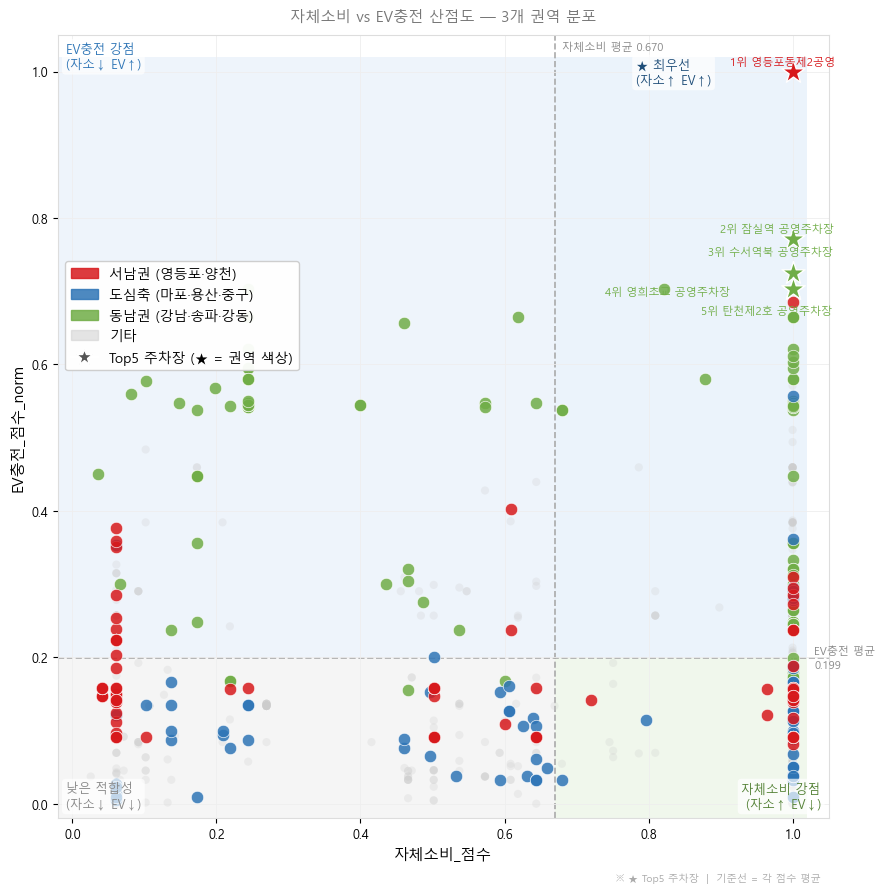

저장 완료 → C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\산점도_3구역_v1.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────
import platform
system = platform.system()
if system == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif system == 'Darwin':
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_bold = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 준비 ───────────────────────────────────────
df_result = pd.read_csv(
    r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\processed\parking_axis3_scored.csv',
    encoding='utf-8-sig'
)

mid_x = df_result['자체소비_점수'].mean()
mid_y = df_result['EV충전_점수_norm'].mean()

# 구역 분류
서남권 = ['영등포구', '양천구']
도심축 = ['마포구', '용산구', '중구']
동남권 = ['송파구', '강동구', '강남구']

def get_region(gu):
    if gu in 서남권:
        return '서남권'
    elif gu in 도심축:
        return '도심축'
    elif gu in 동남권:
        return '동남권'
    else:
        return '기타'

df_result['구역'] = df_result['자치구'].apply(get_region)

# 상위 5개
top5_idx = df_result.nlargest(5, '축3_자가소비적합성').index

# ── 색상 설정 ─────────────────────────────────────────
region_colors = {
    '서남권': '#D7191C',   # 빨강
    '도심축': '#2E75B6',   # 파랑
    '동남권': '#70AD47',   # 초록
    '기타':   '#CCCCCC',   # 회색
}
region_sizes = {
    '서남권': 80,
    '도심축': 80,
    '동남권': 80,
    '기타':   35,
}
region_alphas = {
    '서남권': 0.85,
    '도심축': 0.85,
    '동남권': 0.85,
    '기타':   0.25,
}

# ── 시각화 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 4분면 배경
quad_coords = [
    (mid_x, mid_y, 1.02-mid_x, 1.02-mid_y, '#EBF3FB'),   # 최우선
    (-0.02, mid_y, mid_x+0.02, 1.02-mid_y, '#EEF4FB'),    # EV강점
    (mid_x, -0.02, 1.02-mid_x, mid_y+0.02, '#F0F7EC'),    # 자소강점
    (-0.02, -0.02, mid_x+0.02, mid_y+0.02, '#F5F5F5'),    # 낮은적합
]
for (x0, y0, w, h, color) in quad_coords:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0, y0), w, h,
        boxstyle='square,pad=0',
        facecolor=color, edgecolor='none', zorder=0
    ))

# 기준선
ax.axvline(mid_x, color='#AAAAAA', linewidth=1.2, linestyle='--', zorder=1)
ax.axhline(mid_y, color='#AAAAAA', linewidth=1.2, linestyle='--', zorder=1)

# ── 기타(회색) 먼저 ───────────────────────────────────
other = df_result[(df_result['구역'] == '기타') & (~df_result.index.isin(top5_idx))]
ax.scatter(
    other['자체소비_점수'], other['EV충전_점수_norm'],
    s=35, color='#CCCCCC', alpha=0.25,
    edgecolors='none', zorder=2
)

# ── 3개 구역 ──────────────────────────────────────────
for region in ['동남권', '도심축', '서남권']:
    subset = df_result[
        (df_result['구역'] == region) &
        (~df_result.index.isin(top5_idx))
    ]
    ax.scatter(
        subset['자체소비_점수'], subset['EV충전_점수_norm'],
        s=region_sizes[region],
        color=region_colors[region],
        alpha=region_alphas[region],
        edgecolors='white', linewidths=0.5,
        zorder=3, label=region
    )

# ── Top5 권역별 색상으로 별 표시 ─────────────────────
top5 = df_result.loc[top5_idx].copy()
top5['구역'] = top5['자치구'].apply(get_region)

for _, row in top5.iterrows():
    color = region_colors.get(row['구역'], '#888888')
    ax.scatter(
        row['자체소비_점수'], row['EV충전_점수_norm'],
        s=300,
        color=color,
        marker='*',
        edgecolors='white',
        linewidths=1.0,
        zorder=6
    )

# Top5 라벨
from adjustText import adjust_text
texts = []
for i, (_, row) in enumerate(
    top5.sort_values('축3_자가소비적합성', ascending=False).iterrows()
):
    color = region_colors.get(row['구역'], '#888888')
    t = ax.text(
        row['자체소비_점수'], row['EV충전_점수_norm'],
        f"{i+1}위 {row['pklt_nm']}",
        fontproperties=font_bold,
        fontsize=8,
        color=color,
        zorder=7
    )
    texts.append(t)

adjust_text(
    texts, ax=ax,
    expand_points=(3.0, 3.0),
    expand_text=(2.0, 2.0),
    force_points=(1.5, 1.5),
    force_text=(1.5, 1.5),
)

# ── 4분면 레이블 ──────────────────────────────────────
quad_labels = [
    (0.75, 0.97, '★ 최우선\n(자소↑ EV↑)',    '#1F4E79', 'left',  'top'),
    (0.01, 0.99, 'EV충전 강점\n(자소↓ EV↑)', '#2E75B6', 'left',  'top'),
    (0.99, 0.01, '자체소비 강점\n(자소↑ EV↓)','#538135', 'right', 'bottom'),
    (0.01, 0.01, '낮은 적합성\n(자소↓ EV↓)', '#888888', 'left',  'bottom'),
]
for x, y, text, color, ha, va in quad_labels:
    ax.text(x, y, text,
            transform=ax.transAxes,
            fontproperties=font_bold,
            fontsize=9, color=color,
            ha=ha, va=va,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='none', alpha=0.7))

# 기준선 라벨
ax.text(mid_x + 0.01, 1.03, f'자체소비 평균 {mid_x:.3f}',
        fontproperties=font_prop, fontsize=8,
        color='#888888', ha='left')
ax.text(1.03, mid_y, f'EV충전 평균\n{mid_y:.3f}',
        fontproperties=font_prop, fontsize=8,
        color='#888888', va='center')

# ── 범례 ──────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color=region_colors['서남권'], alpha=0.85, label='서남권 (영등포·양천)'),
    mpatches.Patch(color=region_colors['도심축'], alpha=0.85, label='도심축 (마포·용산·중구)'),
    mpatches.Patch(color=region_colors['동남권'], alpha=0.85, label='동남권 (강남·송파·강동)'),
    mpatches.Patch(color='#CCCCCC', alpha=0.5, label='기타'),
    plt.Line2D([0], [0], marker='*', color='w',
               markerfacecolor='#555555', markersize=12,
               label='Top5 주차장 (★ = 권역 색상)'),
]
ax.legend(
    handles=legend_elements,
    prop=font_prop, fontsize=8.5,
    loc='upper left',
    framealpha=0.95,
    edgecolor='#CCCCCC',
    facecolor='white',
    bbox_to_anchor=(0.0, 0.72)
)

# ── 축 설정 ───────────────────────────────────────────
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('자체소비_점수', fontproperties=font_prop, fontsize=11)
ax.set_ylabel('EV충전_점수_norm', fontproperties=font_prop, fontsize=11)
ax.tick_params(labelsize=9)
ax.grid(color='#EEEEEE', linewidth=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#DDDDDD')

ax.set_title('자체소비 vs EV충전 산점도 — 3개 권역 분포',
             fontproperties=font_prop, fontsize=11,
             color='#777777', pad=10)
ax.annotate(
    '※ ★ Top5 주차장  |  기준선 = 각 점수 평균',
    xy=(0.99, -0.08), xycoords='axes fraction',
    fontproperties=font_prop, fontsize=7.5,
    color='#AAAAAA', ha='right'
)

plt.tight_layout(pad=1.2)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\산점도_3구역_v1.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
plt.close()
print(f"저장 완료 → {save_path}")